In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_150555.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_145527.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_144634.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_155701.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_154546.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_161614.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_150917.jpg
/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_152001.jpg
/kaggle/

In [2]:
# ── Cell 1 — Install packages ────────────────────────────────
!pip install -q grad-cam timm tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# ── Cell 2 — Imports + Seed ──────────────────────────────────
import os
import time
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
import torch
import torch.nn as nn
import torch.optim as optim
import timm
 
from tqdm import tqdm
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
 
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V3_Small_Weights, EfficientNet_B0_Weights
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
 
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
set_seed(42)

In [4]:
 
# ── Cell 3 — Device + Paths ──────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(" No GPU found! Training will be slow.")
 
#  Corrected dataset path — classes sit directly here
BASE_PATH = "/kaggle/input/datasets/tasminarahmanshifa/rice-leaf-and-crop-disease-detection-dataset"
DATASET   = BASE_PATH
FILTERED  = "/kaggle/working/filtered_dataset"
OUT_DIR   = "/kaggle/working/paper_outputs"
 
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "plots"),       exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "gradcam"),     exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "checkpoints"), exist_ok=True)
 
#  Path verify
print("\n--- /kaggle/input ---")
print(os.listdir("/kaggle/input"))
print("\n--- DATASET ---")
print(os.listdir(DATASET))
 

Device: cuda
GPU: Tesla T4

--- /kaggle/input ---
['datasets']

--- DATASET ---
['Tungro', 'Rice Blast', 'Healthy _leaf', 'Bacterial Leaf Blight', 'Rice']


In [54]:
# ── Cell 4 — Config ──────────────────────────────────────────
BATCH_SIZE = 16
CNN_EPOCHS = 20
TRANSFORMER_EPOCHS = 25
 
print(f"Batch size: {BATCH_SIZE} | CNN epochs: {CNN_EPOCHS} | ViT/Swin epochs: {TRANSFORMER_EPOCHS}")
 

Batch size: 16 | CNN epochs: 20 | ViT/Swin epochs: 25


In [6]:
# ── Cell 5 — Dataset Filtering ───────────────────────────────
classes_keep = [
    "Bacterial Leaf Blight",
    "Rice Blast",
    "Tungro",
    "Healthy _leaf"
]
 
if os.path.exists(FILTERED):
    shutil.rmtree(FILTERED)
os.makedirs(FILTERED, exist_ok=True)
 
for c in classes_keep:
    src = os.path.join(DATASET, c)
    dst = os.path.join(FILTERED, c)
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f" Copied: {c}")
    else:
        print(f" Missing class folder: {src}")
 
print("\nFiltered dataset ready.")
 
# ── Image count check ────────────────────────────────────────
from pathlib import Path
 
print("\n Image count per class (after filtering):\n")
total  = 0
counts = {}
 
for cls in classes_keep:
    cls_path = Path(FILTERED) / cls
    imgs = (list(cls_path.rglob("*.jpg")) +
            list(cls_path.rglob("*.png")) +
            list(cls_path.rglob("*.jpeg")))
    counts[cls] = len(imgs)
    total += len(imgs)
    print(f"  {cls:<25} → {len(imgs):>5} images")
 
print(f"\n  {'TOTAL':<25} → {total:>5} images")
 
max_cls = max(counts, key=counts.get)
min_cls = min(counts, key=counts.get)
ratio   = counts[max_cls] / counts[min_cls]
print(f"\n  Imbalance ratio (max/min): {ratio:.2f}x")
 
if ratio > 2.0:
    print("    Significant imbalance detected — WeightedRandomSampler will handle this.")
else:
    print("    Class distribution is reasonably balanced.")
 

 Copied: Bacterial Leaf Blight
 Copied: Rice Blast
 Copied: Tungro
 Copied: Healthy _leaf

Filtered dataset ready.

 Image count per class (after filtering):

  Bacterial Leaf Blight     →   978 images
  Rice Blast                →  3343 images
  Tungro                    →  3745 images
  Healthy _leaf             →  1372 images

  TOTAL                     →  9438 images

  Imbalance ratio (max/min): 3.83x
    Significant imbalance detected — WeightedRandomSampler will handle this.


In [7]:
# ── Cell 6 — Transforms ──────────────────────────────────────
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # more crop variety
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),                       # added vertical flip
    transforms.RandomRotation(30),                         # increased from 20 to 30
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),       # stronger color augmentation
    transforms.RandomGrayscale(p=0.05),                    # occasional grayscale
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)), # blur simulation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))   # random patch erasing
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [8]:
# ── Cell 7 — Stratified Split ────────────────────────────────
dataset_full = datasets.ImageFolder(FILTERED, transform=train_tf)
targets  = np.array(dataset_full.targets)
indices  = np.arange(len(targets))
 
train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=targets, random_state=42
)
temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=42
)
 
train_dataset = datasets.ImageFolder(FILTERED, transform=train_tf)
val_dataset   = datasets.ImageFolder(FILTERED, transform=test_tf)
test_dataset  = datasets.ImageFolder(FILTERED, transform=test_tf)
 
train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset,   val_idx)
test_ds  = Subset(test_dataset,  test_idx)
 
class_names = train_dataset.classes
num_classes = len(class_names)
 
print("Classes:", class_names)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
 

Classes: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']
Train: 7550 | Val: 944 | Test: 944


In [9]:
# ── Cell 8 — DataLoaders + Class Weights + Sampler ───────────
# ✅ Three-layer imbalance handling:
#    1) WeightedRandomSampler  — balanced batches during training
#    2) CrossEntropyLoss(weight=...) — penalises minority misclassification
#    3) Augmented data already included via copytree
 
# ── Class weights for loss function ──────────────────────────
train_targets = np.array([train_dataset.targets[i] for i in train_idx])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_targets),
    y=train_targets
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights_tensor)
 
# ── WeightedRandomSampler ─────────────────────────────────────
sample_weights = torch.tensor(
    [class_weights[t] for t in train_targets], dtype=torch.float
)
 
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
 
# ── DataLoaders ───────────────────────────────────────────────
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    sampler=sampler,               # ✅ replaces shuffle=True
    num_workers=2,
    pin_memory=(device == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(device == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(device == "cuda")
)
 
# ── Verify batch balance ──────────────────────────────────────
batch_x, batch_y = next(iter(train_loader))
batch_counts = Counter(batch_y.numpy())
print("\n✅ Sample batch class distribution:")
for idx, count in sorted(batch_counts.items()):
    print(f"   {class_names[idx]:<25} → {count} samples")
 

Class weights: tensor([2.4137, 1.7190, 0.7059, 0.6300], device='cuda:0')

✅ Sample batch class distribution:
   Healthy _leaf             → 6 samples
   Rice Blast                → 6 samples
   Tungro                    → 4 samples


In [10]:
# ── Cell 9 — Shared Functions ────────────────────────────────
def train_model(model, train_loader, val_loader, class_weights_tensor, device,
                epochs=15, lr=3e-4, weight_decay=0.0,
                checkpoint_path="/kaggle/working/model_best.pth",
                optimizer_type="adam", scheduler_type=None,
                model_name="Model"):

    model.to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

    if optimizer_type == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if scheduler_type == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    train_losses = []
    val_losses   = []

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"{'='*55}")

    for epoch in range(epochs):

        # ── Train phase ────────────────────────────────────
        model.train()
        running_loss               = 0.0
        train_correct, train_total = 0, 0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1:02d}/{epochs} [Train]",
            leave=False,
            ncols=80,
            position=0
        )
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            # ✅ Fixed dim handling
            if out.dim() == 4:
                out = out.mean(dim=[2, 3])
            if out.dim() != 2:
                out = out.view(out.size(0), -1)
            if out.shape[1] != class_weights_tensor.shape[0]:
                raise RuntimeError(f"Model output {out.shape[1]} classes but weight has {class_weights_tensor.shape[0]}")
            loss = loss_fn(out, y)
            loss.backward()
            if optimizer_type == "adamw":
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

            train_correct += (out.argmax(1) == y).sum().item()
            train_total   += y.size(0)

            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / len(train_loader)
        train_acc  = train_correct / train_total
        train_losses.append(epoch_loss)

        # ── Validation phase ───────────────────────────────
        model.eval()
        correct, total   = 0, 0
        val_running_loss = 0.0

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ",
            leave=False,
            ncols=80,
            position=0
        )
        with torch.no_grad():
            for x, y in val_bar:
                x, y = x.to(device), y.to(device)
                out = model(x)
                # ✅ Fixed dim handling
                if out.dim() == 4:
                    out = out.mean(dim=[2, 3])
                if out.dim() != 2:
                    out = out.view(out.size(0), -1)
                val_running_loss += loss_fn(out, y).item()
                preds    = out.argmax(1)
                correct += (preds == y).sum().item()
                total   += y.size(0)

        val_acc  = correct / total
        val_loss = val_running_loss / len(val_loader)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step()

        improved = "✅" if val_acc > best_val_acc else "  "

        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {improved}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)

    print(f"\n  Best Val Acc: {best_val_acc:.4f} — saved to {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return model, train_losses, val_losses


def evaluate(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            if out.dim() == 4:
                out = out.mean(dim=[2, 3])
            if out.dim() != 2:
                out = out.view(out.size(0), -1)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    report = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)
    return all_labels, all_preds, report, cm


def model_info(model, device):
    model.eval()
    params  = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / (1024 ** 2)
    x = torch.randn(1, 3, 224, 224).to(device)

    with torch.inference_mode():
        for _ in range(10):
            _ = model(x)
        if device == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(100):
            _ = model(x)
        if device == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

    latency = elapsed / 100
    fps     = 1 / latency
    return params, size_mb, latency, fps

In [52]:
##To check if the data is balaence:

from collections import Counter

sampled_labels = []

for i, (_, y) in enumerate(train_loader):
    sampled_labels.extend(y.numpy().tolist())
    if i >= 200:
        break

c = Counter(sampled_labels)
total = sum(c.values())

print("Sampled distribution over many batches:\n")
for i, cls in enumerate(class_names):
    print(f"{cls:<25} -> {c[i]} ({c[i]/total:.3f})")




Sampled distribution over many batches:

Bacterial Leaf Blight     -> 803 (0.250)
Healthy _leaf             -> 770 (0.239)
Rice Blast                -> 814 (0.253)
Tungro                    -> 829 (0.258)


In [57]:
# ── Cell 10 — Train CNN: MobileNetV3 ─────────────────────────
model_mobilenet = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
model_mobilenet.classifier[3] = nn.Linear(
    model_mobilenet.classifier[3].in_features, num_classes
)
model_mobilenet, mobilenet_train_losses, mobilenet_val_losses = train_model(
    model_mobilenet, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=CNN_EPOCHS, lr=3e-4,
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "mobilenet_best.pth"),
    optimizer_type="adam",
    model_name="MobileNetV3-Small"
)


  Training: MobileNetV3-Small


  Epoch 01/20 | Train Loss: 0.7090 | Train Acc: 0.5501 | Val Loss: 0.7085 | Val Acc: 0.6208 ✅


  Epoch 02/20 | Train Loss: 0.5335 | Train Acc: 0.6640 | Val Loss: 0.5914 | Val Acc: 0.6769 ✅


  Epoch 03/20 | Train Loss: 0.4448 | Train Acc: 0.7233 | Val Loss: 0.5166 | Val Acc: 0.7341 ✅


  Epoch 04/20 | Train Loss: 0.4107 | Train Acc: 0.7527 | Val Loss: 0.4113 | Val Acc: 0.8178 ✅


...

  Epoch 16/20 | Train Loss: 0.2047 | Train Acc: 0.8890 | Val Loss: 0.3019 | Val Acc: 0.8845   


  Epoch 17/20 | Train Loss: 0.2024 | Train Acc: 0.8939 | Val Loss: 0.3201 | Val Acc: 0.8602   


  Epoch 18/20 | Train Loss: 0.1845 | Train Acc: 0.9016 | Val Loss: 0.3052 | Val Acc: 0.8814   


  Epoch 19/20 | Train Loss: 0.1915 | Train Acc: 0.8968 | Val Loss: 0.2990 | Val Acc: 0.8845   


  Epoch 20/20 | Train Loss: 0.1904 | Train Acc: 0.8962 | Val Loss: 0.2872 | Val Acc: 0.9004 ✅

  Best Val Acc: 0.9004 — saved to /kaggle/working/paper_outputs/checkpoints/mobilenet_best.pth


In [58]:
# ── Cell 11 — Train CNN: EfficientNetB0 ──────────────────────
model_eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_eff.classifier[1] = nn.Linear(
    model_eff.classifier[1].in_features, num_classes
)
model_eff, eff_train_losses, eff_val_losses = train_model(
    model_eff, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=CNN_EPOCHS, lr=3e-4,
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "efficientnet_best.pth"),
    optimizer_type="adam",
    model_name="EfficientNetB0"
)
 


  Training: EfficientNetB0


  Epoch 01/20 | Train Loss: 0.6896 | Train Acc: 0.5657 | Val Loss: 0.9235 | Val Acc: 0.4502 ✅


  Epoch 02/20 | Train Loss: 0.4898 | Train Acc: 0.7007 | Val Loss: 0.4807 | Val Acc: 0.7617 ✅


  Epoch 03/20 | Train Loss: 0.4152 | Train Acc: 0.7542 | Val Loss: 0.4206 | Val Acc: 0.8072 ✅


  Epoch 04/20 | Train Loss: 0.3879 | Train Acc: 0.7830 | Val Loss: 0.3828 | Val Acc: 0.8220 ✅


...

  Epoch 16/20 | Train Loss: 0.1785 | Train Acc: 0.9057 | Val Loss: 0.2613 | Val Acc: 0.8983   


  Epoch 17/20 | Train Loss: 0.1818 | Train Acc: 0.9054 | Val Loss: 0.2180 | Val Acc: 0.9036   


  Epoch 18/20 | Train Loss: 0.1784 | Train Acc: 0.9097 | Val Loss: 0.2561 | Val Acc: 0.9036   


  Epoch 19/20 | Train Loss: 0.1783 | Train Acc: 0.9073 | Val Loss: 0.2298 | Val Acc: 0.9004   


  Epoch 20/20 | Train Loss: 0.1566 | Train Acc: 0.9158 | Val Loss: 0.2100 | Val Acc: 0.9195 ✅

  Best Val Acc: 0.9195 — saved to /kaggle/working/paper_outputs/checkpoints/efficientnet_best.pth


In [59]:
# ── Cell 12 — Train Transformer: ViT-Tiny ────────────────────
model_vit = timm.create_model(
    "vit_tiny_patch16_224", pretrained=True, num_classes=num_classes
)
model_vit, vit_train_losses, vit_val_losses = train_model(
    model_vit, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=TRANSFORMER_EPOCHS, lr=1e-4,
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "vit_best.pth"),
    optimizer_type="adam",
    scheduler_type="cosine",
    model_name="ViT-Tiny"
)
 


  Training: ViT-Tiny


  Epoch 01/25 | Train Loss: 0.7115 | Train Acc: 0.5636 | Val Loss: 0.8495 | Val Acc: 0.4735 ✅


  Epoch 02/25 | Train Loss: 0.5206 | Train Acc: 0.6669 | Val Loss: 0.7426 | Val Acc: 0.5593 ✅


  Epoch 03/25 | Train Loss: 0.4642 | Train Acc: 0.7151 | Val Loss: 0.5390 | Val Acc: 0.6896 ✅


  Epoch 04/25 | Train Loss: 0.4004 | Train Acc: 0.7525 | Val Loss: 0.5169 | Val Acc: 0.7203 ✅


...

  Epoch 21/25 | Train Loss: 0.1242 | Train Acc: 0.9355 | Val Loss: 0.2525 | Val Acc: 0.9089 ✅


  Epoch 22/25 | Train Loss: 0.1188 | Train Acc: 0.9351 | Val Loss: 0.2456 | Val Acc: 0.9078   


  Epoch 23/25 | Train Loss: 0.1177 | Train Acc: 0.9375 | Val Loss: 0.2360 | Val Acc: 0.9057   


  Epoch 24/25 | Train Loss: 0.1081 | Train Acc: 0.9416 | Val Loss: 0.2380 | Val Acc: 0.9078   


  Epoch 25/25 | Train Loss: 0.1154 | Train Acc: 0.9339 | Val Loss: 0.2375 | Val Acc: 0.9068   

  Best Val Acc: 0.9089 — saved to /kaggle/working/paper_outputs/checkpoints/vit_best.pth


In [60]:
# ── Cell 13 — Train Transformer: Swin-Tiny ───────────────────
num_classes = len(class_names)
class_weights_tensor = torch.tensor(
    compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=np.array([train_dataset.targets[i] for i in train_idx])
    ),
    dtype=torch.float
).to(device)

print(f"num_classes          = {num_classes}")
print(f"weight shape         = {class_weights_tensor.shape}")

# ✅ Wrap Swin with a custom pooling + classifier head
class SwinWithHead(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224", pretrained=True, num_classes=0
        )
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # handles any spatial output
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)           # [B, H*W, C] or [B, C, H, W]
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])     # [B, C]
        elif x.dim() == 3:
            x = x.mean(dim=1)          # [B, C]
        x = nn.functional.dropout(x, p=0.3, training=self.training)
        x = nn.Linear(x.shape[1], num_classes).to(x.device)(x)
        return x

#  Simpler and more reliable approach
model_swin = timm.create_model(
    "swin_tiny_patch4_window7_224", pretrained=True, num_classes=0
)
in_features = model_swin.num_features

class SwinClassifier(nn.Module):
    def __init__(self, backbone, in_features, num_classes):
        super().__init__()
        self.backbone = backbone
        self.dropout  = nn.Dropout(0.3)
        self.fc       = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])   # [B, C, H, W] → [B, C]
        elif x.dim() == 3:
            x = x.mean(dim=1)        # [B, H*W, C] → [B, C]
        x = self.dropout(x)
        return self.fc(x)

model_swin = SwinClassifier(model_swin, in_features, num_classes)

# Verify before training
model_swin.to(device)
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out   = model_swin(dummy)
    print(f"Model output shape   = {out.shape}")  # must be [2, 4]
assert out.shape[1] == num_classes, f"Head mismatch: got {out.shape[1]}, expected {num_classes}"

model_swin, swin_train_losses, swin_val_losses = train_model(
    model_swin, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=TRANSFORMER_EPOCHS, lr=1e-4, weight_decay=0.05,
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "swin_best.pth"),
    optimizer_type="adamw",
    scheduler_type="cosine",
    model_name="Swin-Tiny"
)

num_classes          = 4
weight shape         = torch.Size([4])
Model output shape   = torch.Size([2, 4])

  Training: Swin-Tiny


  Epoch 01/25 | Train Loss: 0.7418 | Train Acc: 0.5519 | Val Loss: 0.6862 | Val Acc: 0.6419 ✅


  Epoch 02/25 | Train Loss: 0.5337 | Train Acc: 0.6878 | Val Loss: 0.6630 | Val Acc: 0.6314   


  Epoch 03/25 | Train Loss: 0.4502 | Train Acc: 0.7359 | Val Loss: 0.4805 | Val Acc: 0.7574 ✅


  Epoch 04/25 | Train Loss: 0.3839 | Train Acc: 0.7866 | Val Loss: 0.3996 | Val Acc: 0.8072 ✅


...

  Epoch 21/25 | Train Loss: 0.1304 | Train Acc: 0.9400 | Val Loss: 0.2877 | Val Acc: 0.9121   


  Epoch 22/25 | Train Loss: 0.1245 | Train Acc: 0.9437 | Val Loss: 0.2815 | Val Acc: 0.9195   


  Epoch 23/25 | Train Loss: 0.1263 | Train Acc: 0.9461 | Val Loss: 0.2950 | Val Acc: 0.9195   


  Epoch 24/25 | Train Loss: 0.1180 | Train Acc: 0.9453 | Val Loss: 0.2915 | Val Acc: 0.9206   


  Epoch 25/25 | Train Loss: 0.1175 | Train Acc: 0.9458 | Val Loss: 0.2888 | Val Acc: 0.9206   

  Best Val Acc: 0.9227 — saved to /kaggle/working/paper_outputs/checkpoints/swin_best.pth


In [61]:
# ── Cell 14 — Evaluate All 4 Models ─────────────────────────
all_models = {
    "MobileNetV3-Small":    model_mobilenet,
    "EfficientNetB0": model_eff,
    "ViT-Tiny":       model_vit,
    "Swin-Tiny":      model_swin
}

all_reports       = {}
all_model_metrics = {}

for name, model in all_models.items():
    print(f"\nEvaluating {name}...")
    labels, preds, report, cm    = evaluate(model, test_loader, class_names, device)
    params, size_mb, latency, fps = model_info(model, device)  

    all_reports[name]       = report
    all_model_metrics[name] = {
        "accuracy":           report["accuracy"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted":    report["weighted avg"]["recall"],
        "weighted_f1":        report["weighted avg"]["f1-score"],
        "macro_f1":           report["macro avg"]["f1-score"],
        "params_M":           round(params / 1e6, 2),  
        "size_mb":            size_mb,
        "latency_ms":         latency * 1000,
        "fps":                fps,
        "cm":                 cm
    }

    print(f"  Accuracy: {report['accuracy']:.4f} | "
          f"Weighted F1: {report['weighted avg']['f1-score']:.4f} | "
          f"Params: {round(params/1e6, 2)}M | "  
          f"Size: {size_mb:.2f} MB | "
          f"Latency: {latency*1000:.2f} ms | "
          f"FPS: {fps:.2f}")

summary_df = pd.DataFrame(all_model_metrics).T[[
    "accuracy", "precision_weighted", "recall_weighted",
    "weighted_f1", "macro_f1", "params_M", "size_mb", "latency_ms", "fps"
]].sort_values(by="accuracy", ascending=False)

print("\n=== Summary Table ===")
display(summary_df)
summary_df.to_csv(os.path.join(OUT_DIR, "model_summary_results.csv"))


Evaluating MobileNetV3-Small...
  Accuracy: 0.9174 | Weighted F1: 0.9196 | Params: 1.52M | Size: 5.81 MB | Latency: 5.06 ms | FPS: 197.48

Evaluating EfficientNetB0...
  Accuracy: 0.9206 | Weighted F1: 0.9230 | Params: 4.01M | Size: 15.31 MB | Latency: 8.65 ms | FPS: 115.60

Evaluating ViT-Tiny...
  Accuracy: 0.9184 | Weighted F1: 0.9210 | Params: 5.53M | Size: 21.08 MB | Latency: 4.77 ms | FPS: 209.47

Evaluating Swin-Tiny...
  Accuracy: 0.9248 | Weighted F1: 0.9266 | Params: 27.52M | Size: 104.99 MB | Latency: 10.46 ms | FPS: 95.57

=== Summary Table ===


,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,params_M,size_mb,latency_ms,fps
Swin-Tiny,0.924788,0.935977,0.924788,0.926563,0.906981,27.52,104.989738,10.464078,95.565035
EfficientNetB0,0.920551,0.935173,0.920551,0.922981,0.905681,4.01,15.307129,8.650709,115.597464
ViT-Tiny,0.918432,0.937237,0.918432,0.920985,0.901822,5.53,21.07692,4.773848,209.474608
MobileNetV3-Small,0.917373,0.932419,0.917373,0.919639,0.900188,1.52,5.805801,5.063697,197.484157


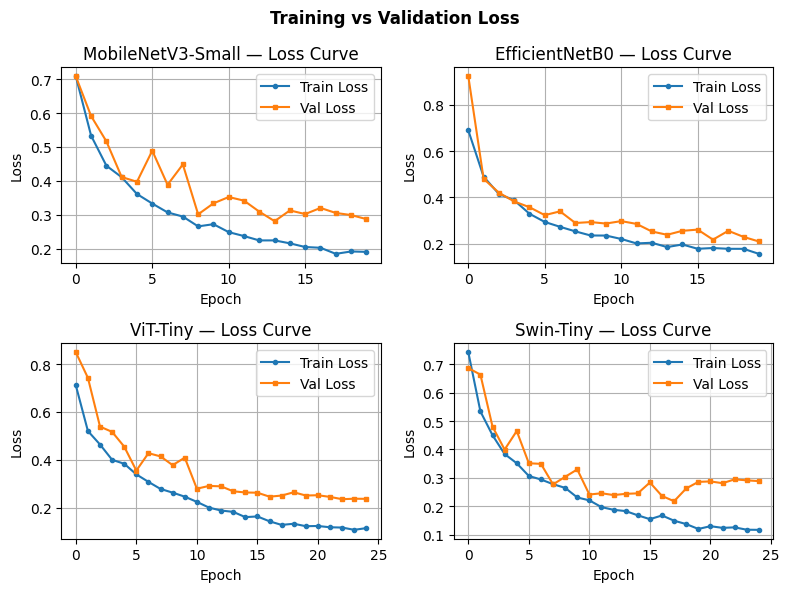

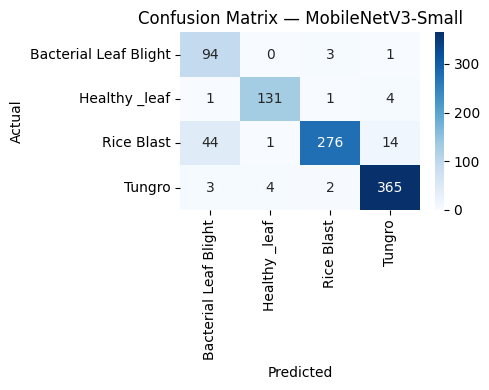

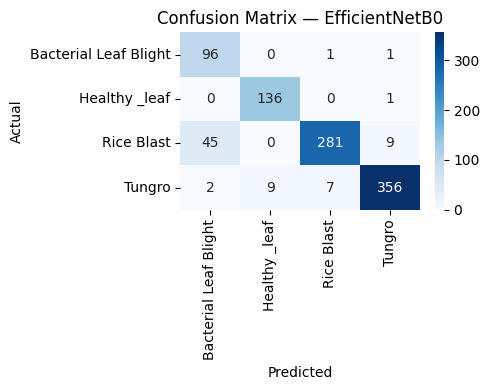

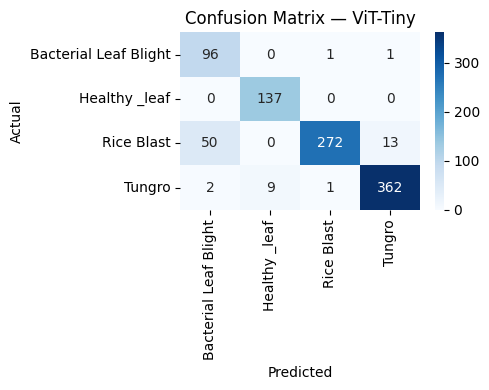

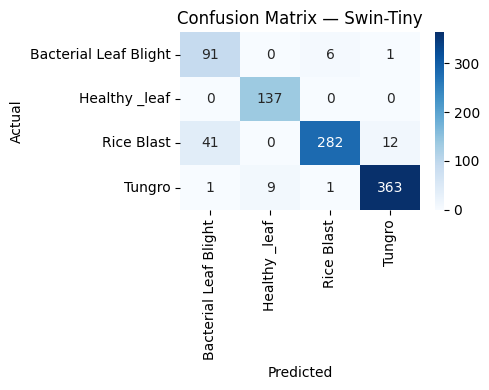

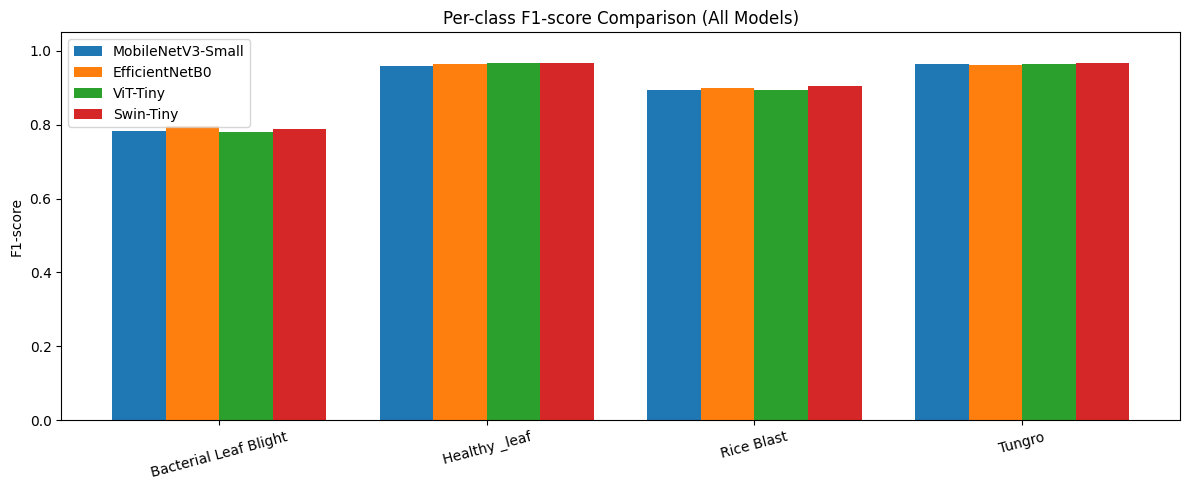

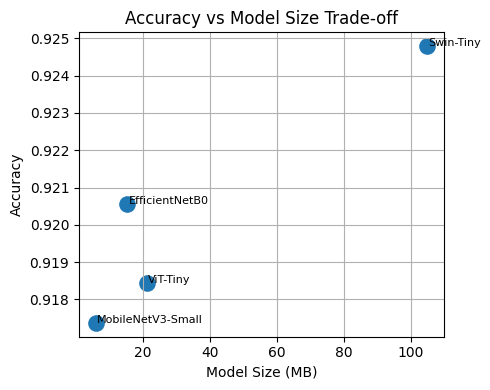

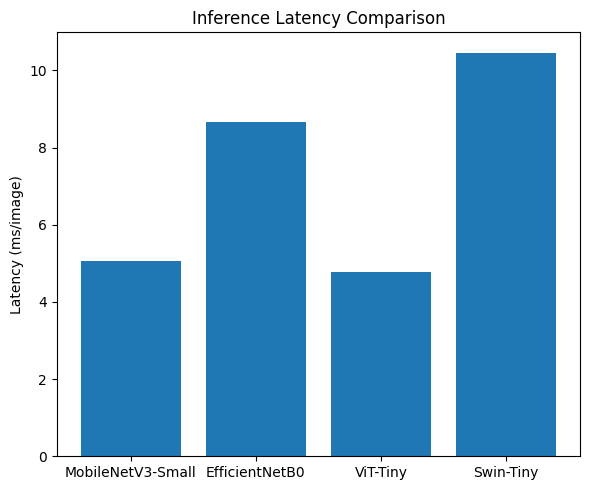

In [66]:
# ── Cell 15 — Plots ──────────────────────────────────────────
plot_models = ["MobileNetV3-Small", "EfficientNetB0", "ViT-Tiny", "Swin-Tiny"]
 
# ── 1) Loss Curves ────────────────────────────────────────────
all_train_losses = {
    "MobileNetV3-Small":    mobilenet_train_losses,
    "EfficientNetB0": eff_train_losses,
    "ViT-Tiny":       vit_train_losses,
    "Swin-Tiny":      swin_train_losses
}
all_val_losses = {
    "MobileNetV3-Small":    mobilenet_val_losses,
    "EfficientNetB0": eff_val_losses,
    "ViT-Tiny":       vit_val_losses,
    "Swin-Tiny":      swin_val_losses
}
 
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
for i, name in enumerate(plot_models):
    axes[i].plot(all_train_losses[name], label="Train Loss", marker='o', markersize=3)
    axes[i].plot(all_val_losses[name],   label="Val Loss",   marker='s', markersize=3)
    axes[i].set_title(f"{name} — Loss Curve")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)
 
plt.suptitle("Training vs Validation Loss", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plots", "loss_curves.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "plots", "loss_curves.pdf"), bbox_inches="tight")
plt.show()
 
# ── 2) Confusion Matrices ────────────────────────────────────
for name in plot_models:
    cm = all_model_metrics[name]["cm"]
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "plots", f"{name}_confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(OUT_DIR, "plots", f"{name}_confusion_matrix.pdf"), bbox_inches="tight")
    plt.show()
 
# ── 3) Per-class F1 ──────────────────────────────────────────
x     = np.arange(len(class_names))
width = 0.2
 
plt.figure(figsize=(12, 5))
for i, model_name in enumerate(plot_models):
    f1_scores = [all_reports[model_name][cls]["f1-score"] for cls in class_names]
    offset    = (i - 1.5) * width
    plt.bar(x + offset, f1_scores, width=width, label=model_name)
 
plt.xticks(x, class_names, rotation=15)
plt.ylabel("F1-score")
plt.title("Per-class F1-score Comparison (All Models)")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plots", "per_class_f1_comparison.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "plots", "per_class_f1_comparison.pdf"), bbox_inches="tight")
plt.show()
 
# ── 4) Accuracy vs Model Size ────────────────────────────────
acc  = [all_model_metrics[m]["accuracy"] for m in plot_models]
size = [all_model_metrics[m]["size_mb"]  for m in plot_models]
 
plt.figure(figsize=(5, 4))
plt.scatter(size, acc, s=120)
for i, m in enumerate(plot_models):
    plt.text(size[i] + 0.3, acc[i], m, fontsize=8)
plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size Trade-off")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plots", "accuracy_vs_model_size.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "plots", "accuracy_vs_model_size.pdf"), bbox_inches="tight")
plt.show()
 
# ── 5) Latency Comparison ────────────────────────────────────
latencies = [all_model_metrics[m]["latency_ms"] for m in plot_models]
 
plt.figure(figsize=(6, 5))
plt.bar(plot_models, latencies)
plt.ylabel("Latency (ms/image)")
plt.title("Inference Latency Comparison")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plots", "latency_comparison.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "plots", "latency_comparison.pdf"), bbox_inches="tight")
plt.show()
 

Finding 1 sample per class for Grad-CAM...


  3%|▊                     | 33/944 [00:00<00:14, 63.14it/s]


Selected indices: [33, 1, 6, 0]
Classes: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']


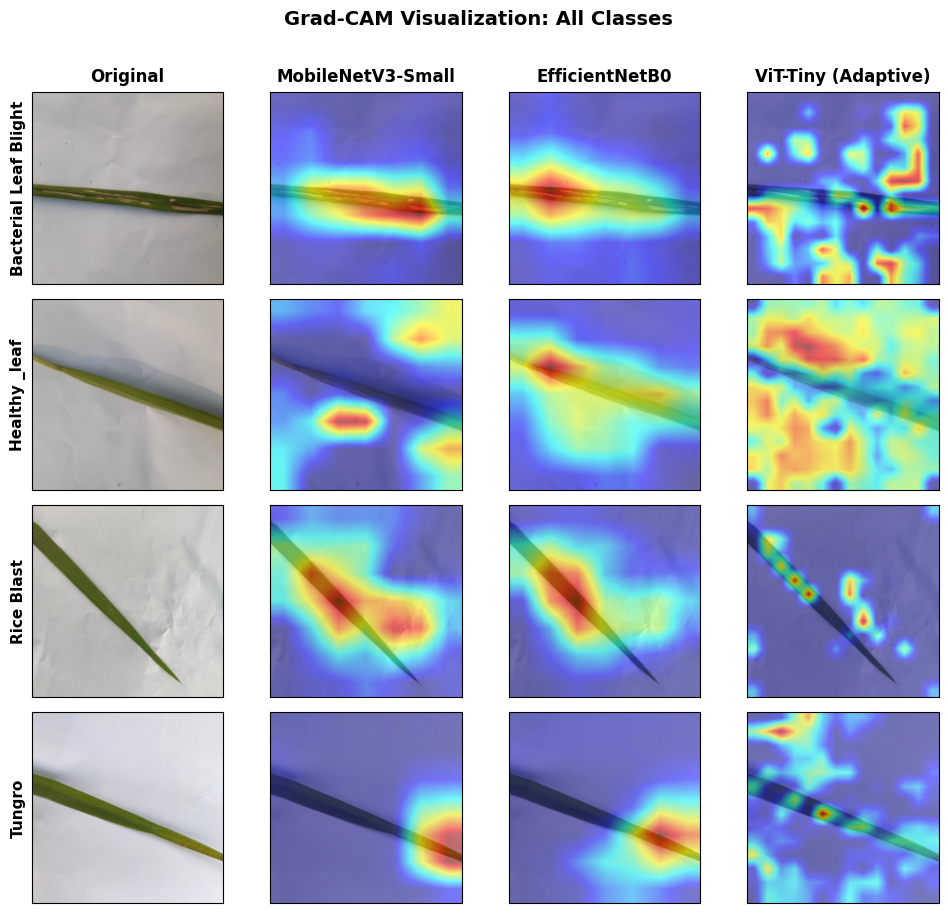

 Grad-CAM grid saved!


In [68]:
# ── Cell 16 — Grad-CAM (4×4 Grid) ────────────────────────────
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

def denormalize_image(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * inv_std) + inv_mean
    return np.clip(img, 0, 1)

def reshape_transform_vit(tensor, height=14, width=14):
    tensor = tensor[:, 1:, :]
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    return result.permute(0, 3, 1, 2)

def get_prediction(model, img_tensor):
    model.eval()
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        pred = out.argmax(dim=1).item()
    return pred

# Grad-CAM Model Selection Rationale:
# ─────────────────────────────────────────────────────────────
# • MobileNetV3-Small    → Lightweight CNN (efficiency representative)
# • EfficientNetB0 → Deep CNN (accuracy representative)
# • ViT-Tiny       → Transformer (adaptive reshape_transform)
# Swin-Tiny EXCLUDED: shifted-window attention produces
# non-standard spatial tensors incompatible with Grad-CAM
# (Chefer et al. 2021; Wang et al. 2022)
# ─────────────────────────────────────────────────────────────

selected_gradcam_models = {
    "MobileNetV3-Small":    model_mobilenet,
    "EfficientNetB0": model_eff,
    "ViT-Tiny":       model_vit
}

# ── 1 sample per class ───────────────────────────────────────
print("Finding 1 sample per class for Grad-CAM...")
seen_classes = {}
for idx in tqdm(range(len(test_ds)), ncols=60):
    img, label = test_ds[idx]
    if label in seen_classes:
        continue
    ok = all(get_prediction(m, img) == label
             for m in selected_gradcam_models.values())
    if ok:
        seen_classes[label] = idx
    if len(seen_classes) == num_classes:
        break

sample_indices = [seen_classes[c] for c in sorted(seen_classes.keys())]
print("Selected indices:", sample_indices)
print("Classes:", [class_names[test_ds[i][1]] for i in sample_indices])

# ── 4×4 Grid Figure ──────────────────────────────────────────
col_labels = ["Original", "MobileNetV3-Small", "EfficientNetB0", "ViT-Tiny (Adaptive)"]
n_rows = len(sample_indices)
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 9))  # ✅ compact

for row, idx in enumerate(sample_indices):
    img, label   = test_ds[idx]
    input_tensor = img.unsqueeze(0).to(device)
    rgb_img      = denormalize_image(img)

    axes[row, 0].imshow(rgb_img)
    axes[row, 0].set_ylabel(class_names[label], fontsize=11, fontweight='bold')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    model_mobilenet.eval()
    with torch.no_grad():
        pred_mobile = model_mobilenet(input_tensor).argmax(dim=1).item()
    cam_mobile  = GradCAM(model=model_mobilenet,
                          target_layers=[model_mobilenet.features[-1]])
    gray_mobile = cam_mobile(input_tensor=input_tensor,
                             targets=[ClassifierOutputTarget(pred_mobile)])[0]
    axes[row, 1].imshow(show_cam_on_image(rgb_img, gray_mobile, use_rgb=True))
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])

    model_eff.eval()
    with torch.no_grad():
        pred_eff = model_eff(input_tensor).argmax(dim=1).item()
    cam_eff  = GradCAM(model=model_eff,
                       target_layers=[model_eff.features[-1]])
    gray_eff = cam_eff(input_tensor=input_tensor,
                       targets=[ClassifierOutputTarget(pred_eff)])[0]
    axes[row, 2].imshow(show_cam_on_image(rgb_img, gray_eff, use_rgb=True))
    axes[row, 2].set_xticks([])
    axes[row, 2].set_yticks([])

    model_vit.eval()
    with torch.no_grad():
        pred_vit = model_vit(input_tensor).argmax(dim=1).item()
    cam_vit = GradCAM(model=model_vit,
                      target_layers=[model_vit.blocks[-1].norm1],
                      reshape_transform=reshape_transform_vit)
    gray_vit = cam_vit(input_tensor=input_tensor,
                       targets=[ClassifierOutputTarget(pred_vit)])[0]
    axes[row, 3].imshow(show_cam_on_image(rgb_img, gray_vit, use_rgb=True))
    axes[row, 3].set_xticks([])
    axes[row, 3].set_yticks([])

for col, title in enumerate(col_labels):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=8)

plt.suptitle("Grad-CAM Visualization: All Classes",
             fontsize=14, fontweight='bold', y=1.01) 

plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "gradcam", "gradcam_grid_paper.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "gradcam", "gradcam_grid_paper.pdf"),
            bbox_inches="tight")
plt.show()
print(" Grad-CAM grid saved!")

In [71]:
# ── Cell 17 — Final Output Summary ───────────────────────────
OUT_DIR = "/kaggle/working/paper_outputs"

print("\n" + "="*55)
print("   All outputs saved to:", OUT_DIR)
print("="*55)
print("  plots/loss_curves.pdf")
print("  plots/per_class_f1_comparison.pdf")
print("  plots/accuracy_vs_model_size.pdf")
print("  plots/latency_comparison.pdf")
print("  plots/[model]_confusion_matrix.pdf")
print("  gradcam/gradcam_grid_paper.pdf")   
print("  model_summary_results.csv")


   All outputs saved to: /kaggle/working/paper_outputs
  plots/loss_curves.pdf
  plots/per_class_f1_comparison.pdf
  plots/accuracy_vs_model_size.pdf
  plots/latency_comparison.pdf
  plots/[model]_confusion_matrix.pdf
  gradcam/gradcam_grid_paper.pdf
  model_summary_results.csv
